# 01 — Análise Exploratória (EDA)

**Projeto:** Churn Prediction & Retention  
**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Semana 1:** base tratada, entendimento do problema e preparação inicial

Este notebook cobre:
- Carregamento e inspeção da base
- Descrição inicial dos atributos
- Tratamento de valores ausentes e duplicidades
- Identificação preliminar de outliers
- Transformação inicial de atributos categóricos
- Primeira análise exploratória e exportação da base limpa

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "telco_clean.csv"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dataset: {RAW_PATH}")

Projeto: /home/andre-luiz/personal/churn-prediction-and-retention
Dataset: /home/andre-luiz/personal/churn-prediction-and-retention/data/raw/Telco-Customer-Churn.csv


## 1. Carregamento dos dados

In [2]:
if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {RAW_PATH}\n"
        "Baixe o CSV do Kaggle e salve em data/raw/Telco-Customer-Churn.csv"
    )

df_raw = pd.read_csv(RAW_PATH)
df = df_raw.copy()

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Inspeção inicial

In [3]:
print("Tipos de dados:")
print(df.dtypes)
print("\nResumo numérico:")
display(df.describe(include="all").T)

Tipos de dados:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Resumo numérico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Descrição inicial dos atributos

| Grupo | Atributos | Papel |
|---|---|---|
| Identificação | `customerID` | Chave do cliente — removido na modelagem |
| Demográficos | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Perfil do assinante |
| Relacionamento | `tenure` | Meses como cliente |
| Serviços | telefonia, internet e add-ons | Comportamento de uso |
| Contrato/cobrança | `Contract`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` | Compromisso e valor |
| Alvo | `Churn` | Cliente cancelou? (Yes/No) |

In [4]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

print("Cardinalidade dos categóricos:")
for col in categorical_cols:
    print(f"  {col:20s} → {df[col].nunique():3d} valores únicos | top: {df[col].mode().iloc[0]}")

Cardinalidade dos categóricos:
  customerID           → 7043 valores únicos | top: 0002-ORFBO
  gender               →   2 valores únicos | top: Male
  Partner              →   2 valores únicos | top: No
  Dependents           →   2 valores únicos | top: No
  PhoneService         →   2 valores únicos | top: Yes
  MultipleLines        →   3 valores únicos | top: No
  InternetService      →   3 valores únicos | top: Fiber optic
  OnlineSecurity       →   3 valores únicos | top: No
  OnlineBackup         →   3 valores únicos | top: No
  DeviceProtection     →   3 valores únicos | top: No
  TechSupport          →   3 valores únicos | top: No
  StreamingTV          →   3 valores únicos | top: No
  StreamingMovies      →   3 valores únicos | top: No
  Contract             →   3 valores únicos | top: Month-to-month
  PaperlessBilling     →   2 valores únicos | top: Yes
  PaymentMethod        →   4 valores únicos | top: Electronic check
  TotalCharges         → 6531 valores únicos | top:  
  C

## 4. Tratamento de valores ausentes

`TotalCharges` vem como texto e contém espaços em branco para clientes com `tenure = 0`.

In [5]:
print("Valores ausentes explícitos (NaN):")
print(df.isna().sum()[lambda s: s > 0])

blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"\nTotalCharges em branco (espaços): {blank_total_charges}")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_after_coerce = df["TotalCharges"].isna().sum()
print(f"TotalCharges inválidos após conversão: {missing_after_coerce}")

# Clientes novos (tenure=0) sem cobrança acumulada → imputar 0
df.loc[df["TotalCharges"].isna(), "TotalCharges"] = 0

print("\nValores ausentes após tratamento:")
missing_final = df.isna().sum()
missing_final = missing_final[missing_final > 0]
print(missing_final if len(missing_final) else "Nenhum valor ausente.")

Valores ausentes explícitos (NaN):
Series([], dtype: int64)

TotalCharges em branco (espaços): 11
TotalCharges inválidos após conversão: 11

Valores ausentes após tratamento:
Nenhum valor ausente.


## 5. Tratamento de duplicidades

In [6]:
dup_rows = df.duplicated().sum()
dup_ids = df["customerID"].duplicated().sum()

print(f"Linhas duplicadas (todas as colunas): {dup_rows}")
print(f"customerID duplicados: {dup_ids}")

if dup_rows > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Linhas removidas: {dup_rows}")

print(f"Shape após deduplicação: {df.shape}")

Linhas duplicadas (todas as colunas): 0
customerID duplicados: 0
Shape após deduplicação: (7043, 21)


## 6. Identificação preliminar de outliers

Usamos o método **IQR** nos atributos numéricos contínuos. Valores extremos são registrados, mas não removidos nesta etapa — `tenure = 0` representa clientes novos, não erro.

In [7]:
def iqr_outliers(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
outlier_report = {}

for col in outlier_cols:
    mask = iqr_outliers(df[col])
    outlier_report[col] = {
        "count": int(mask.sum()),
        "pct": round(mask.mean() * 100, 2),
        "min": df.loc[mask, col].min() if mask.any() else None,
        "max": df.loc[mask, col].max() if mask.any() else None,
    }

pd.DataFrame(outlier_report).T

,count,pct,min,max
tenure,0.0,0.0,NaN,NaN
MonthlyCharges,0.0,0.0,NaN,NaN
TotalCharges,0.0,0.0,NaN,NaN


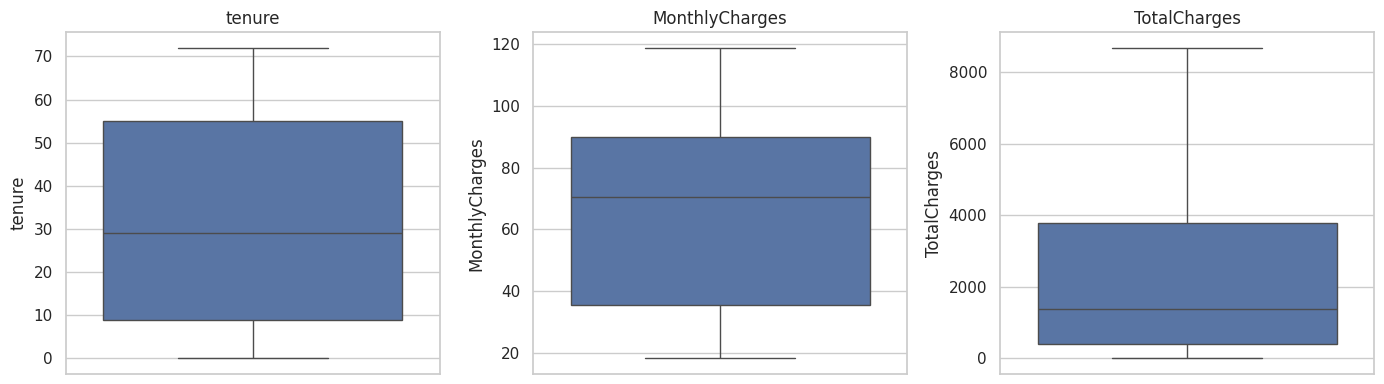

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "01_outliers_boxplot.png", bbox_inches="tight")
plt.show()

## 7. Transformação inicial de atributos categóricos

- **Binários Yes/No** → mapeamento 0/1
- **`Contract`** → ordem ordinal (Month-to-month < One year < Two year)
- **`Churn`** (alvo) → Yes=1, No=0
- **`customerID`** → mantido apenas para rastreio; será removido na modelagem

One-Hot Encoding completo será aplicado no notebook `02_preprocessing`.

In [9]:
binary_yes_no = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

contract_order = {"Month-to-month": 0, "One year": 1, "Two year": 2}
service_map = {"No": 0, "Yes": 1, "No internet service": -1, "No phone service": -1}

df["gender_label"] = df["gender"].map({"Male": 0, "Female": 1})
df["Contract_ordinal"] = df["Contract"].map(contract_order)
df["Churn_label"] = df["Churn"].map({"No": 0, "Yes": 1})

for col in binary_yes_no:
    df[f"{col}_binary"] = df[col].map({"No": 0, "Yes": 1})

for col in service_cols:
    df[f"{col}_binary"] = df[col].map(service_map)

print("Mapeamentos aplicados:")
print(f"  Churn_label: {df['Churn_label'].value_counts().to_dict()}")
print(f"  Contract_ordinal:\n{df.groupby('Contract')['Contract_ordinal'].first()}")
print(f"  Serviços com categoria N/A (-1): {df['OnlineSecurity_binary'].eq(-1).sum()} registros")
df[["gender", "gender_label", "Contract", "Contract_ordinal", "Churn", "Churn_label"]].head()

Mapeamentos aplicados:
  Churn_label: {0: 5174, 1: 1869}
  Contract_ordinal:
Contract
Month-to-month    0
One year          1
Two year          2
Name: Contract_ordinal, dtype: int64
  Serviços com categoria N/A (-1): 1526 registros


,gender,gender_label,Contract,Contract_ordinal,Churn,Churn_label
0,Female,1,Month-to-month,0,No,0
1,Male,0,One year,1,No,0
2,Male,0,Month-to-month,0,Yes,1
3,Male,0,One year,1,No,0
4,Female,1,Month-to-month,0,Yes,1


## 8. Primeira análise exploratória

### 8.1 Variável alvo — desbalanceamento de classes

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção: No=73.5% | Yes=26.5%


/tmp/ipykernel_20813/221172688.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", order=["No", "Yes"], ax=ax, palette=["#4C72B0", "#DD8452"])


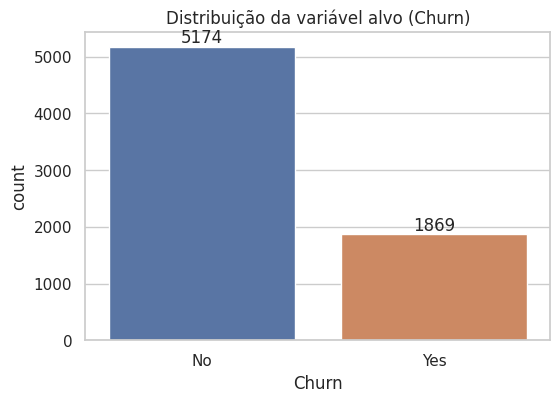

In [10]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nProporção: No={churn_pct['No']:.1f}% | Yes={churn_pct['Yes']:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], ax=ax, palette=["#4C72B0", "#DD8452"])
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
ax.set_title("Distribuição da variável alvo (Churn)")
plt.savefig(FIGURES_PATH / "02_churn_distribution.png", bbox_inches="tight")
plt.show()

### 8.2 Churn por tipo de contrato e serviço de internet

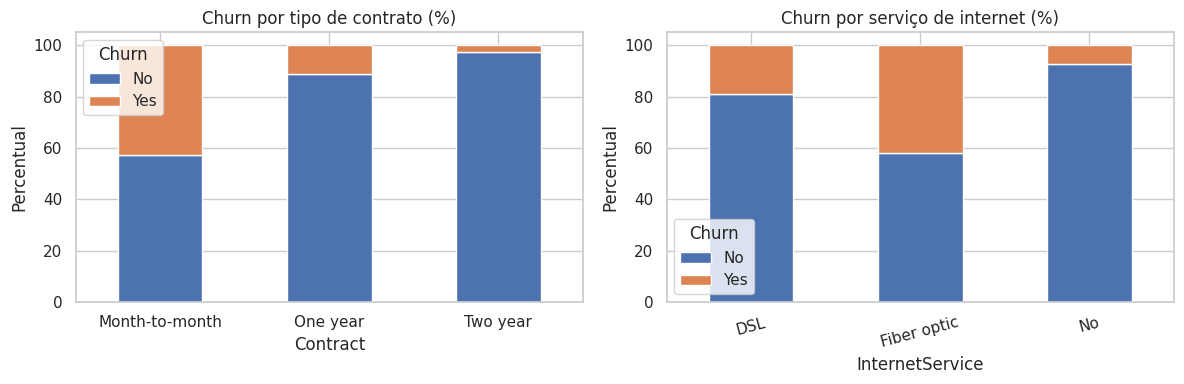

Taxa de churn por contrato:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Churn por tipo de contrato (%)")
axes[0].set_ylabel("Percentual")
axes[0].legend(title="Churn")
axes[0].tick_params(axis="x", rotation=0)

internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Churn por serviço de internet (%)")
axes[1].set_ylabel("Percentual")
axes[1].legend(title="Churn")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "03_churn_contract_internet.png", bbox_inches="tight")
plt.show()

print("Taxa de churn por contrato:")
print((contract_churn["Yes"].sort_values(ascending=False).round(1).astype(str) + "%").to_string())

### 8.3 Tenure e cobranças mensais vs. churn

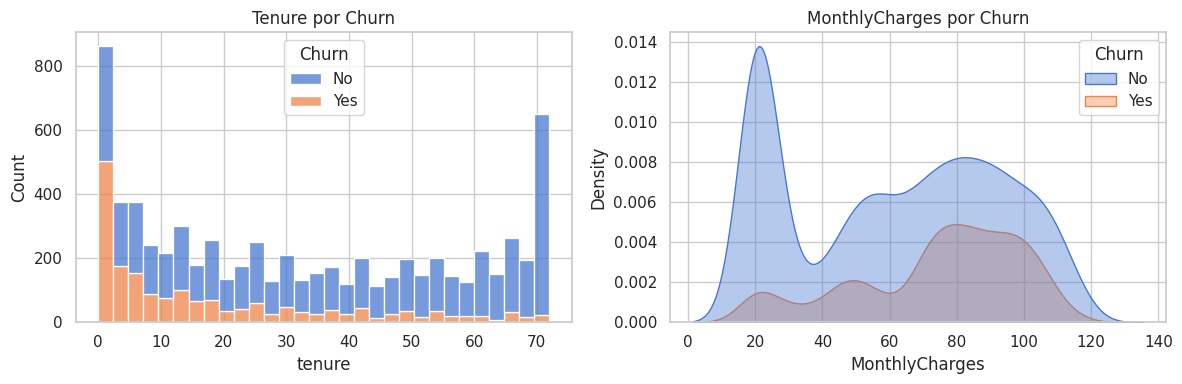

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=axes[0])
axes[0].set_title("Tenure por Churn")

sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("MonthlyCharges por Churn")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "04_tenure_monthly_charges.png", bbox_inches="tight")
plt.show()

### 8.4 Correlação entre atributos numéricos

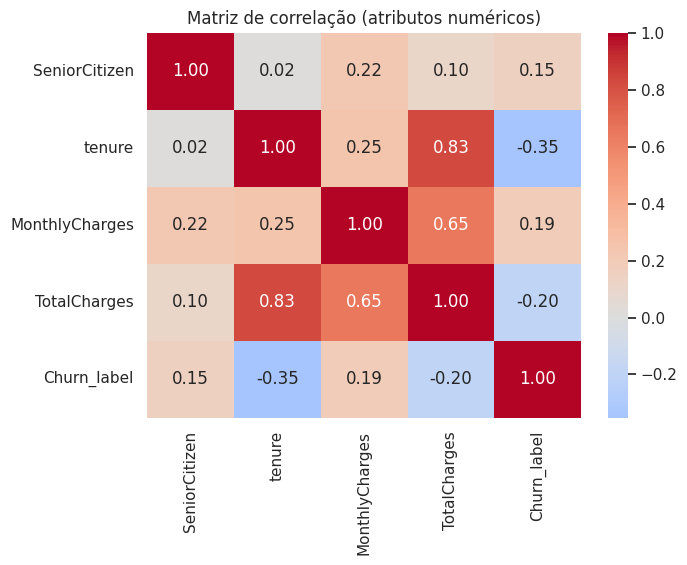

Observação: MonthlyCharges, TotalCharges e tenure são fortemente correlacionados.


In [13]:
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn_label"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação (atributos numéricos)")
plt.savefig(FIGURES_PATH / "05_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Observação: MonthlyCharges, TotalCharges e tenure são fortemente correlacionados.")

### 8.5 Hipóteses iniciais

1. Contratos **Month-to-month** apresentam taxa de churn superior a contratos anuais/bianuais.
2. Clientes com **Fiber optic** tendem a cancelar mais — possível insatisfação com custo-benefício.
3. **Baixo tenure** e **MonthlyCharges elevadas** concentram risco de cancelamento.
4. **TotalCharges** é derivável de `tenure × MonthlyCharges` — exige cuidado com multicolinearidade na modelagem.

## 9. Exportar base tratada

In [14]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print(f"Base limpa salva em: {PROCESSED_PATH}")
print(f"Shape final: {df.shape}")
print(f"Figuras salvas em: {FIGURES_PATH}")

Base limpa salva em: /home/andre-luiz/personal/churn-prediction-and-retention/data/processed/telco_clean.csv
Shape final: (7043, 35)
Figuras salvas em: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures
